# 1. Setup and Configuration


In [1]:
# Install required packages
!pip install -q transformers==4.44.2 datasets==2.21.0 scikit-learn==1.5.1 accelerate==0.34.2 evaluate==0.4.2



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 155.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 154.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 125.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.1 which is incompatible.
hdbsc

In [4]:
import json
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Files are uploaded directly to /content/ in Colab (not Google Drive)
DATA_DIR = Path("/content")
LORA_DIR = Path("/content")
OUTPUT_DIR = Path("/content/classifier_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Device: NVIDIA A100-SXM4-40GB


# 2. Data Loading and Preprocessing



In [5]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

train_raw = load_json(DATA_DIR / "train.json")
val_raw = load_json(DATA_DIR / "val.json")
test_raw = load_json(DATA_DIR / "test.json")

print(f"Train: {len(train_raw)} | Val: {len(val_raw)} | Test: {len(test_raw)}")
print("Sample:", train_raw[0])

# 6 emotion labels (fixed order)
EMOTION_LABELS = ["determined", "worried", "angry", "happy", "sad", "neutral"]
label2id = {l: i for i, l in enumerate(EMOTION_LABELS)}
id2label = {i: l for i, l in enumerate(EMOTION_LABELS)}

# Convert string labels to integer ids
def to_int_label(data):
    return [{"text": x["text"], "label": label2id[x["label"]]} for x in data]

train_data = to_int_label(train_raw)
val_data = to_int_label(val_raw)
test_data = to_int_label(test_raw)

# Show class distribution and save it for the report
def show_distribution(data, name):
    counter = Counter([id2label[x["label"]] for x in data])
    print(f"\n{name} distribution:")
    for label in EMOTION_LABELS:
        print(f"  {label:12s}: {counter.get(label, 0)}")
    return counter

train_dist = show_distribution(train_data, "Train")
val_dist = show_distribution(val_data, "Val")
test_dist = show_distribution(test_data, "Test")

# Save distribution as CSV for the final report
dist_df = pd.DataFrame({
    "emotion": EMOTION_LABELS,
    "train": [train_dist.get(l, 0) for l in EMOTION_LABELS],
    "val": [val_dist.get(l, 0) for l in EMOTION_LABELS],
    "test": [test_dist.get(l, 0) for l in EMOTION_LABELS],
})
dist_df.to_csv(OUTPUT_DIR / "class_distribution.csv", index=False)
print("\nSaved class_distribution.csv")

Train: 478 | Val: 58 | Test: 64
Sample: {'text': "There's nothing there, Harry.", 'label': 'neutral'}

Train distribution:
  determined  : 98
  worried     : 115
  angry       : 50
  happy       : 18
  sad         : 13
  neutral     : 184

Val distribution:
  determined  : 12
  worried     : 14
  angry       : 6
  happy       : 2
  sad         : 1
  neutral     : 23

Test distribution:
  determined  : 13
  worried     : 15
  angry       : 7
  happy       : 3
  sad         : 3
  neutral     : 23

Saved class_distribution.csv


In [6]:
# Class weights: inversely proportional to class frequency
# Formula: weight_c = N_total / (num_classes * N_c)
# This is the "balanced" formula from sklearn (matches Lecture 05 reweighting idea)
train_label_counts = np.array([
    train_dist.get(label, 0) for label in EMOTION_LABELS
])
total_samples = train_label_counts.sum()
num_classes = len(EMOTION_LABELS)

# Add a small epsilon to avoid division by zero (in case any class has 0 samples)
class_weights = total_samples / (num_classes * (train_label_counts + 1e-6))

print("Class weights (higher = rarer class, gets more loss penalty):")
for label, w in zip(EMOTION_LABELS, class_weights):
    print(f"  {label:12s}: weight={w:.3f}  (n={train_dist.get(label, 0)})")

# Convert to torch tensor and move to GPU
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(
    torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

Class weights (higher = rarer class, gets more loss penalty):
  determined  : weight=0.813  (n=98)
  worried     : weight=0.693  (n=115)
  angry       : weight=1.593  (n=50)
  happy       : weight=4.426  (n=18)
  sad         : weight=6.128  (n=13)
  neutral     : weight=0.433  (n=184)


In [7]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    # Truncate long sentences to 128 tokens; padding done dynamically by collator
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,
    )

train_ds = Dataset.from_list(train_data).map(tokenize_function, batched=True)
val_ds = Dataset.from_list(val_data).map(tokenize_function, batched=True)
test_ds = Dataset.from_list(test_data).map(tokenize_function, batched=True)

# Dynamic padding: pads to longest sequence in each batch (saves GPU memory)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenized example:", {k: train_ds[0][k] for k in ["input_ids", "attention_mask", "label"]})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/478 [00:00<?, ? examples/s]

Map:   0%|          | 0/58 [00:00<?, ? examples/s]

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

Tokenized example: {'input_ids': [101, 2045, 1005, 1055, 2498, 2045, 1010, 4302, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'label': 5}


# 3. Model Components

Define the weighted Trainer (handles class imbalance via reweighted cross-entropy), evaluation metrics, and the reusable training loop.

In [8]:
class WeightedTrainer(Trainer):
    """Custom Trainer that uses weighted cross-entropy loss for class imbalance."""

    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        # Weighted cross-entropy: rare classes get higher loss penalty
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [9]:
def compute_metrics(eval_pred):
    """Compute accuracy and F1 during training."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

def evaluate_on_test(trainer, test_dataset, version_name):
    """Full test evaluation with confusion matrix saved to disk."""
    predictions = trainer.predict(test_dataset)
    pred_labels = np.argmax(predictions.predictions, axis=-1)
    true_labels = predictions.label_ids

    acc = accuracy_score(true_labels, pred_labels)
    f1_macro = f1_score(true_labels, pred_labels, average="macro")
    f1_weighted = f1_score(true_labels, pred_labels, average="weighted")

    print(f"\n=== {version_name} Test Results ===")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro F1:    {f1_macro:.4f}")
    print(f"Weighted F1: {f1_weighted:.4f}")

    report = classification_report(
        true_labels, pred_labels,
        labels=list(range(len(EMOTION_LABELS))),
        target_names=EMOTION_LABELS,
        digits=3,
        zero_division=0,
    )
    print("\nPer-class report:")
    print(report)

    # Save report as text file
    with open(OUTPUT_DIR / f"classification_report_{version_name}.txt", "w") as f:
        f.write(f"=== {version_name} Test Results ===\n")
        f.write(f"Accuracy:    {acc:.4f}\n")
        f.write(f"Macro F1:    {f1_macro:.4f}\n")
        f.write(f"Weighted F1: {f1_weighted:.4f}\n\n")
        f.write(report)

    # Confusion matrix figure
    cm = confusion_matrix(true_labels, pred_labels, labels=list(range(len(EMOTION_LABELS))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix: {version_name}")
    plt.tight_layout()
    save_path = OUTPUT_DIR / f"confusion_matrix_{version_name}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {save_path}")

    return {
        "version": version_name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "predictions": pred_labels,
        "true_labels": true_labels,
    }

In [11]:
def train_classifier(
    train_dataset,
    val_dataset,
    output_subdir,
    learning_rate=2e-5,
    num_epochs=8,
    batch_size=16,
    dropout_rate=0.1,
    use_class_weights=True,
    seed=SEED,
):
    """Train BERT classifier with weighted loss + early stopping."""

    save_dir = OUTPUT_DIR / output_subdir
    save_dir.mkdir(parents=True, exist_ok=True)

    # Load fresh model with classification head + dropout
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(EMOTION_LABELS),
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=dropout_rate,
        attention_probs_dropout_prob=dropout_rate,
    )

    training_args = TrainingArguments(
        output_dir=str(save_dir / "checkpoints"),
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=learning_rate,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_dir=str(save_dir / "logs"),
        logging_steps=20,
        save_total_limit=2,
        seed=seed,
        report_to="none",
        warmup_ratio=0.1,
    )

    trainer = WeightedTrainer(
        class_weights=class_weights_tensor if use_class_weights else None,
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    # Save best model + tokenizer
    trainer.save_model(str(save_dir / "best_model"))
    tokenizer.save_pretrained(str(save_dir / "best_model"))

    # Save training log for plotting later
    log_history = trainer.state.log_history
    with open(save_dir / "log_history.json", "w") as f:
        json.dump(log_history, f, indent=2)

    return trainer

# 4. Iteration 1: Baseline Classifier (v1)

Train BERT on original 478 movie lines. Evaluate on test set. Use v1 to predict 100 LoRA-generated sentences as a distribution shift diagnostic.

Training Classifier v1: original data + class weighting


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.853300,1.775856,0.431034,0.136604,0.290541
2,1.738300,1.694303,0.413793,0.319391,0.412261
3,1.651400,1.583219,0.500000,0.282906,0.474845
4,1.380800,1.452112,0.534483,0.430962,0.535777
5,1.302400,1.404474,0.603448,0.479111,0.578519
6,1.097800,1.351744,0.551724,0.442910,0.526110
7,0.961400,1.303633,0.620690,0.672222,0.614713
8,0.869100,1.289820,0.620690,0.667298,0.614655



=== v1 Test Results ===
Accuracy:    0.5000
Macro F1:    0.4096
Weighted F1: 0.4841

Per-class report:
              precision    recall  f1-score   support

  determined      0.500     0.308     0.381        13
     worried      0.235     0.267     0.250        15
       angry      0.375     0.429     0.400         7
       happy      0.667     0.667     0.667         3
         sad      0.000     0.000     0.000         3
     neutral      0.704     0.826     0.760        23

    accuracy                          0.500        64
   macro avg      0.413     0.416     0.410        64
weighted avg      0.482     0.500     0.484        64



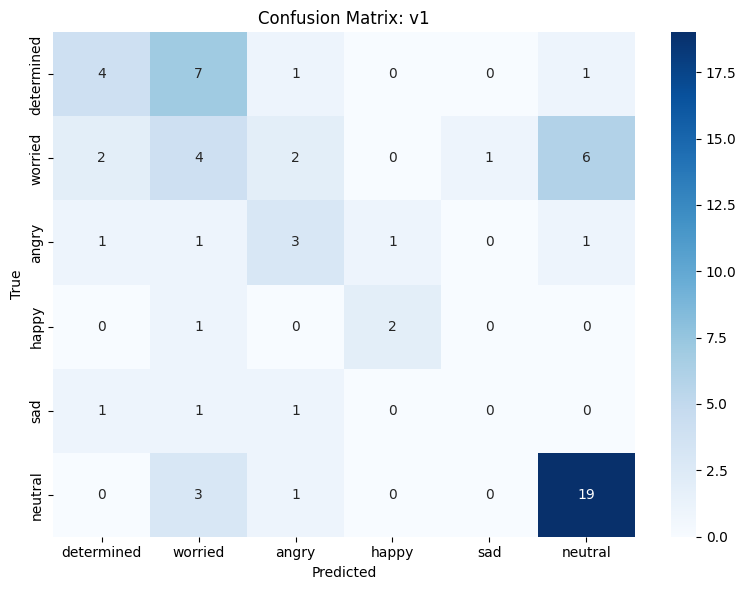

Saved figure: /content/classifier_outputs/confusion_matrix_v1.png


In [12]:
print("=" * 60)
print("Training Classifier v1: original data + class weighting")
print("=" * 60)

trainer_v1 = train_classifier(
    train_dataset=train_ds,
    val_dataset=val_ds,
    output_subdir="v1",
    learning_rate=2e-5,
    num_epochs=8,
    batch_size=16,
    dropout_rate=0.1,
    use_class_weights=True,
)

results_v1 = evaluate_on_test(trainer_v1, test_ds, "v1")

In [13]:
LORA_GEN_PATH = LORA_DIR / "lora_generated_100.json"
lora_generated = load_json(LORA_GEN_PATH)
print(f"Loaded {len(lora_generated)} LoRA-generated sentences")
print("First item keys:", list(lora_generated[0].keys()))
print("First item:", lora_generated[0])

# This file uses 'response' as the text field (not 'text')
TEXT_FIELD = "response"
lora_texts = [item[TEXT_FIELD] for item in lora_generated]

# Use v1 model to predict
v1_model = trainer_v1.model
v1_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
v1_model.to(device)

def predict_batch(texts, model, tokenizer, batch_size=16):
    """Run model on a list of texts, return predicted label ids and probs."""
    all_preds, all_probs = [], []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(
            batch,
            padding=True, truncation=True, max_length=128,
            return_tensors="pt",
        ).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = np.argmax(probs, axis=-1)
        all_preds.extend(preds.tolist())
        all_probs.extend(probs.tolist())
    return all_preds, all_probs

lora_preds_v1, lora_probs_v1 = predict_batch(lora_texts, v1_model, tokenizer)

# Save inspection table
inspection = pd.DataFrame({
    "text": lora_texts,
    "predicted_v1": [id2label[p] for p in lora_preds_v1],
    "max_prob_v1": [max(p) for p in lora_probs_v1],
})
inspection.to_csv(OUTPUT_DIR / "lora_predictions_v1.csv", index=False)

print("\nv1 prediction distribution on LoRA-generated text:")
print(inspection["predicted_v1"].value_counts())
print(f"\nAverage prediction confidence: {inspection['max_prob_v1'].mean():.3f}")

# Show 10 lowest-confidence cases
print("\nTop 10 lowest-confidence predictions (v1 was unsure):")
low_conf = inspection.sort_values("max_prob_v1").head(10)
for _, r in low_conf.iterrows():
    print(f"  [{r['predicted_v1']:11s} p={r['max_prob_v1']:.2f}] {r['text'][:80]}")

Loaded 100 LoRA-generated sentences
First item keys: ['id', 'source_emotion', 'context_used', 'source', 'response', 'predicted_emotion']
First item: {'id': 1, 'source_emotion': 'determined', 'context_used': 'I will master this spell no matter how long it takes.', 'source': 'synthetic', 'response': "I'm sure you can do that, Harry!  It's not hard once the steps are memorized -- just like everything else we've learned at Hogwarts...", 'predicted_emotion': 'determined'}

v1 prediction distribution on LoRA-generated text:
predicted_v1
worried       49
determined    24
angry         10
happy         10
neutral        6
sad            1
Name: count, dtype: int64

Average prediction confidence: 0.375

Top 10 lowest-confidence predictions (v1 was unsure):
  [worried     p=0.21] I'm Harry Potter, of course...  But I'd rather not be known for that. It's just 
  [sad         p=0.22] I'm sorry, I just wanted to see them up close...it's not like they're yours! The
  [angry       p=0.24] Don't worry

# 5. Iteration 2: Augmented Classifier (v2)

Reuse pre-labeled LoRA outputs (100 sentences labeled by API in stage 3) as additional training data. Retrain BERT with the same hyperparameters to isolate the effect of data augmentation. Compare v1 vs v2.

In [14]:
# Reuse existing labels from lora_generated_100.json
LORA_GEN_PATH = LORA_DIR / "lora_generated_100.json"
lora_generated = load_json(LORA_GEN_PATH)
print(f"Loaded {len(lora_generated)} pre-labeled LoRA-generated sentences")

# Build the standard {"text", "label"}
lora_labeled = [
    {"text": item["response"], "label": item["predicted_emotion"]}
    for item in lora_generated
]

# Validate all labels are in the 6-class set
invalid = [x for x in lora_labeled if x["label"] not in EMOTION_LABELS]
if invalid:
    print(f"WARNING: {len(invalid)} items have labels outside the 6-class set:")
    for x in invalid[:5]:
        print(f"  label={x['label']!r}: {x['text'][:60]}")
else:
    print("All labels valid.")

# Save in standard format for downstream use
labeled_path = OUTPUT_DIR / "lora_generated_100_labeled.json"
with open(labeled_path, "w", encoding="utf-8") as f:
    json.dump(lora_labeled, f, ensure_ascii=False, indent=2)
print(f"Saved: {labeled_path}")

# Show label distribution on LoRA outputs
print("\nLabel distribution on LoRA-generated text:")
print(pd.Series([x["label"] for x in lora_labeled]).value_counts())

# Quick sanity check: compare with v1 predictions to compute "agreement"
# (This is a useful diagnostic for the iteration log)
inspection["api_label"] = [item["label"] for item in lora_labeled]
inspection["v1_matches_api"] = inspection["predicted_v1"] == inspection["api_label"]
agreement_rate = inspection["v1_matches_api"].mean()
print(f"\nv1 classifier agrees with API labels on: {agreement_rate:.2%} of LoRA outputs")
inspection.to_csv(OUTPUT_DIR / "lora_predictions_v1_with_api.csv", index=False)

Loaded 100 pre-labeled LoRA-generated sentences
All labels valid.
Saved: /content/classifier_outputs/lora_generated_100_labeled.json

Label distribution on LoRA-generated text:
worried       41
determined    26
neutral       13
happy         12
angry          5
sad            3
Name: count, dtype: int64

v1 classifier agrees with API labels on: 65.00% of LoRA outputs


Original train: 478 | Augmented train: 578

Augmented class distribution + weights:
  determined  : n= 124  weight=0.777
  worried     : n= 156  weight=0.618
  angry       : n=  55  weight=1.752
  happy       : n=  30  weight=3.211
  sad         : n=  16  weight=6.021
  neutral     : n= 197  weight=0.489


Map:   0%|          | 0/578 [00:00<?, ? examples/s]

Training Classifier v2: augmented data + class weighting


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.808300,1.739677,0.258621,0.122222,0.165517
2,1.724600,1.675939,0.172414,0.109829,0.117683
3,1.539600,1.451342,0.568966,0.366209,0.552627
4,1.264200,1.259769,0.534483,0.517749,0.548411
5,0.984100,1.106520,0.637931,0.592710,0.642999
6,0.769800,1.043253,0.620690,0.532946,0.627239
7,0.688300,0.999640,0.689655,0.672113,0.689131
8,0.546200,1.007414,0.672414,0.611958,0.676409



=== v2 Test Results ===
Accuracy:    0.5469
Macro F1:    0.4533
Weighted F1: 0.5456

Per-class report:
              precision    recall  f1-score   support

  determined      0.667     0.308     0.421        13
     worried      0.429     0.600     0.500        15
       angry      0.444     0.571     0.500         7
       happy      0.500     0.667     0.571         3
         sad      0.000     0.000     0.000         3
     neutral      0.762     0.696     0.727        23

    accuracy                          0.547        64
   macro avg      0.467     0.474     0.453        64
weighted avg      0.582     0.547     0.546        64



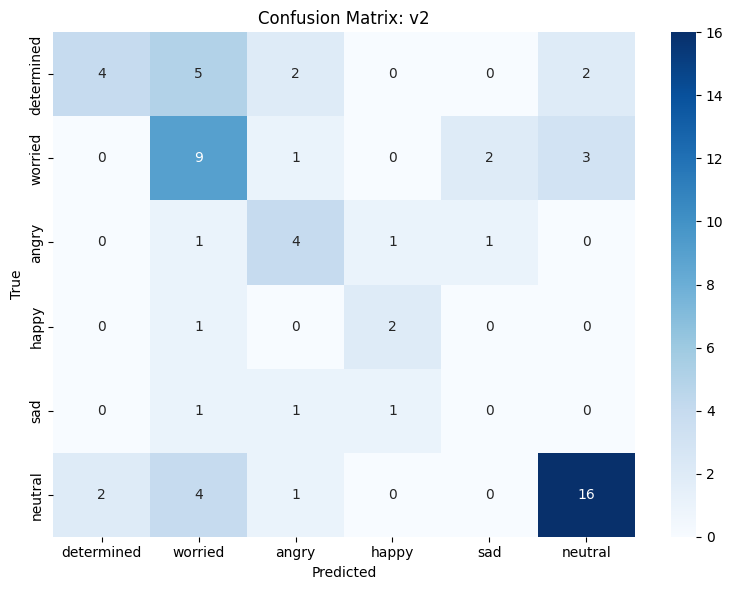

Saved figure: /content/classifier_outputs/confusion_matrix_v2.png


In [26]:
# Iteration 2: train v2 on augmented dataset (original 478 + 100 LoRA labeled)
augmented_train_data = train_data + [
    {"text": x["text"], "label": label2id[x["label"]]}
    for x in lora_labeled
]
print(f"Original train: {len(train_data)} | Augmented train: {len(augmented_train_data)}")

# Recompute class weights for augmented set (distribution shifts slightly)
aug_counts = Counter([x["label"] for x in augmented_train_data])
aug_label_counts = np.array([aug_counts.get(i, 0) for i in range(len(EMOTION_LABELS))])
aug_total = aug_label_counts.sum()
aug_weights = aug_total / (len(EMOTION_LABELS) * (aug_label_counts + 1e-6))

print("\nAugmented class distribution + weights:")
for label, n, w in zip(EMOTION_LABELS, aug_label_counts, aug_weights):
    print(f"  {label:12s}: n={n:4d}  weight={w:.3f}")

# Update the global tensor used by WeightedTrainer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.tensor(aug_weights, dtype=torch.float).to(device)

augmented_train_ds = Dataset.from_list(augmented_train_data).map(tokenize_function, batched=True)

print("=" * 60)
print("Training Classifier v2: augmented data + class weighting")
print("=" * 60)

trainer_v2 = train_classifier(
    train_dataset=augmented_train_ds,
    val_dataset=val_ds,
    output_subdir="v2",
    learning_rate=2e-5,
    num_epochs=8,
    batch_size=16,
    dropout_rate=0.1,
    use_class_weights=True,
)

results_v2 = evaluate_on_test(trainer_v2, test_ds, "v2")

In [27]:
# v1 vs v2 comparison table
comparison = pd.DataFrame([
    {
        "version": "v1 (original 478)",
        "train_size": len(train_data),
        "test_accuracy": results_v1["accuracy"],
        "test_f1_macro": results_v1["f1_macro"],
        "test_f1_weighted": results_v1["f1_weighted"],
    },
    {
        "version": "v2 (augmented 578)",
        "train_size": len(augmented_train_data),
        "test_accuracy": results_v2["accuracy"],
        "test_f1_macro": results_v2["f1_macro"],
        "test_f1_weighted": results_v2["f1_weighted"],
    },
])
comparison["delta_f1_macro"] = comparison["test_f1_macro"].diff()
comparison.to_csv(OUTPUT_DIR / "classifier_comparison_v1_v2.csv", index=False)
print(comparison.to_string(index=False))

           version  train_size  test_accuracy  test_f1_macro  test_f1_weighted  delta_f1_macro
 v1 (original 478)         478       0.500000       0.409603          0.484100             NaN
v2 (augmented 578)         578       0.546875       0.453292          0.545551        0.043689


# 6. Hyperparameter Tuning

Sweep dropout rate over {0.1, 0.2, 0.3} on the augmented dataset

Tuning: dropout_rate=0.1


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.854700,1.746515,0.086207,0.026455,0.016420
2,1.728700,1.521253,0.517241,0.349804,0.496748
3,1.408500,1.342053,0.568966,0.368113,0.545259
4,1.051800,1.099296,0.620690,0.524516,0.616836
5,0.795600,1.019401,0.689655,0.617434,0.692561
6,0.562700,0.963777,0.672414,0.534545,0.663511
7,0.489200,0.948162,0.724138,0.671212,0.717189
8,0.377700,0.966467,0.724138,0.571440,0.723438



=== dropout_0.1 Test Results ===
Accuracy:    0.5312
Macro F1:    0.4243
Weighted F1: 0.5161

Per-class report:
              precision    recall  f1-score   support

  determined      0.500     0.308     0.381        13
     worried      0.444     0.533     0.485        15
       angry      0.375     0.429     0.400         7
       happy      0.500     0.667     0.571         3
         sad      0.000     0.000     0.000         3
     neutral      0.680     0.739     0.708        23

    accuracy                          0.531        64
   macro avg      0.417     0.446     0.424        64
weighted avg      0.515     0.531     0.516        64



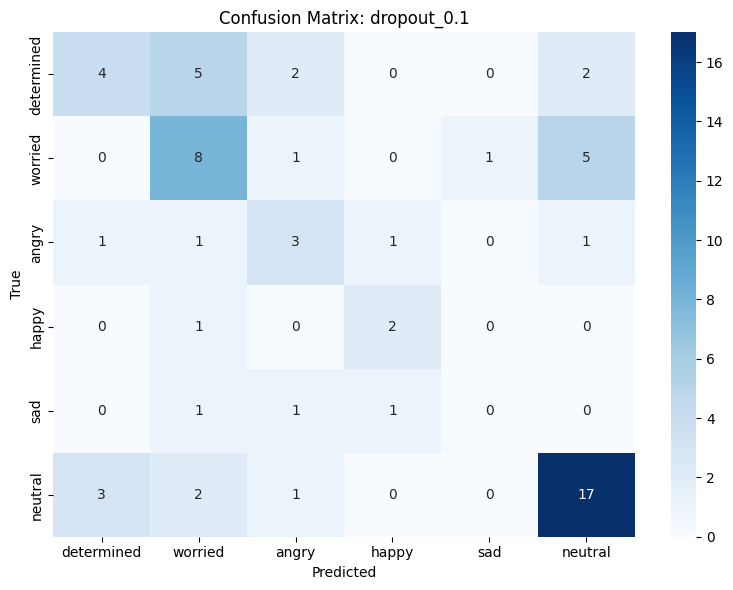

Saved figure: /content/classifier_outputs/confusion_matrix_dropout_0.1.png
Tuning: dropout_rate=0.2


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.840700,1.753203,0.086207,0.026882,0.016685
2,1.772600,1.682227,0.396552,0.265989,0.382194
3,1.592400,1.509224,0.603448,0.393747,0.579535
4,1.397600,1.360630,0.568966,0.384601,0.554897
5,1.243400,1.282084,0.551724,0.373832,0.547014



=== dropout_0.2 Test Results ===
Accuracy:    0.4531
Macro F1:    0.3148
Weighted F1: 0.4447

Per-class report:
              precision    recall  f1-score   support

  determined      0.438     0.538     0.483        13
     worried      0.500     0.333     0.400        15
       angry      0.312     0.714     0.435         7
       happy      0.000     0.000     0.000         3
         sad      0.000     0.000     0.000         3
     neutral      0.632     0.522     0.571        23

    accuracy                          0.453        64
   macro avg      0.314     0.351     0.315        64
weighted avg      0.467     0.453     0.445        64



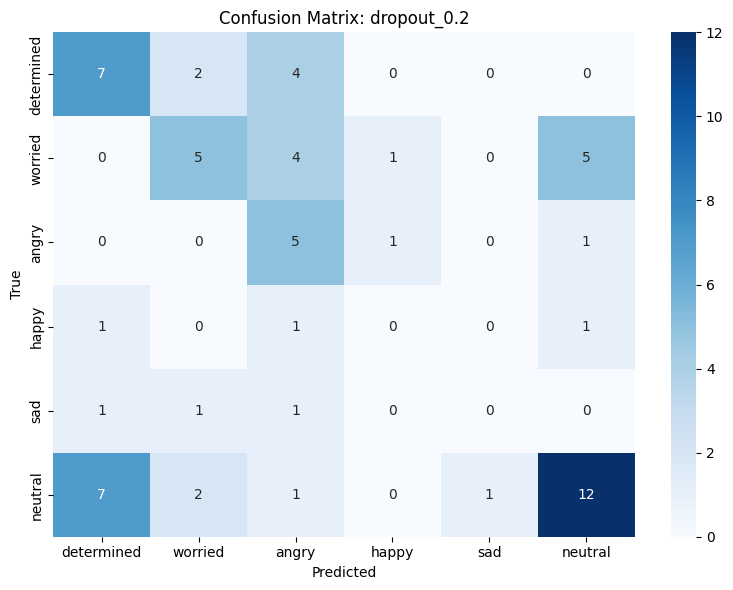

Saved figure: /content/classifier_outputs/confusion_matrix_dropout_0.2.png
Tuning: dropout_rate=0.3


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.802200,1.748965,0.327586,0.137593,0.263167
2,1.774800,1.711532,0.344828,0.215476,0.323153
3,1.709400,1.687970,0.310345,0.171012,0.228165
4,1.636000,1.636668,0.293103,0.209495,0.254044



=== dropout_0.3 Test Results ===
Accuracy:    0.2656
Macro F1:    0.1283
Weighted F1: 0.1890

Per-class report:
              precision    recall  f1-score   support

  determined      0.000     0.000     0.000        13
     worried      0.255     0.867     0.394        15
       angry      0.167     0.143     0.154         7
       happy      0.000     0.000     0.000         3
         sad      0.000     0.000     0.000         3
     neutral      0.750     0.130     0.222        23

    accuracy                          0.266        64
   macro avg      0.195     0.190     0.128        64
weighted avg      0.348     0.266     0.189        64



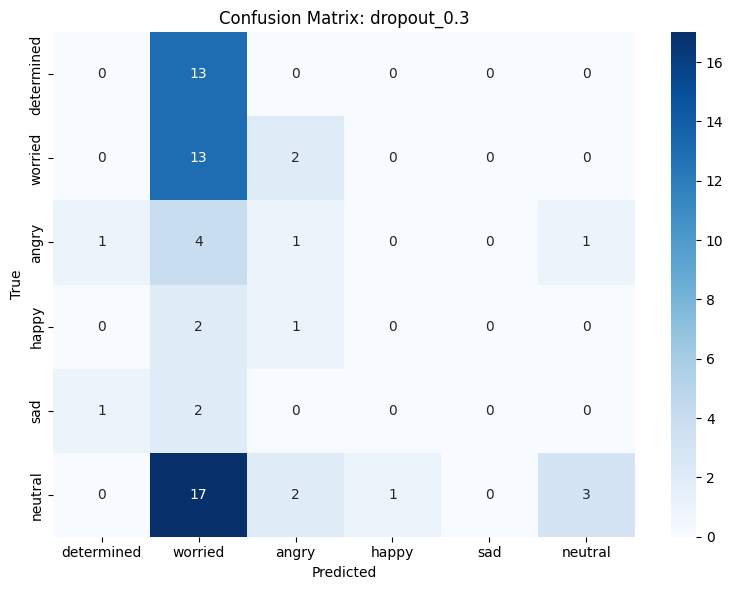

Saved figure: /content/classifier_outputs/confusion_matrix_dropout_0.3.png

=== Hyperparameter Tuning Results ===
 dropout_rate  test_accuracy  test_f1_macro  test_f1_weighted
          0.1       0.531250       0.424260          0.516110
          0.2       0.453125       0.314828          0.444722
          0.3       0.265625       0.128335          0.189018

Best dropout rate by macro-F1: 0.1
Best macro-F1: 0.4243


In [28]:
# Hyperparameter tuning: dropout rate, on the augmented dataset
DROPOUT_RATES = [0.1, 0.2, 0.3]
hp_results = []

for dr in DROPOUT_RATES:
    print("=" * 60)
    print(f"Tuning: dropout_rate={dr}")
    print("=" * 60)

    trainer_dr = train_classifier(
        train_dataset=augmented_train_ds,
        val_dataset=val_ds,
        output_subdir=f"dropout_{dr}",
        learning_rate=2e-5,
        num_epochs=8,
        batch_size=16,
        dropout_rate=dr,
        use_class_weights=True,
    )
    res = evaluate_on_test(trainer_dr, test_ds, f"dropout_{dr}")
    hp_results.append({
        "dropout_rate": dr,
        "test_accuracy": res["accuracy"],
        "test_f1_macro": res["f1_macro"],
        "test_f1_weighted": res["f1_weighted"],
    })

    # Free GPU memory between runs
    del trainer_dr
    torch.cuda.empty_cache()

hp_df = pd.DataFrame(hp_results)
hp_df.to_csv(OUTPUT_DIR / "classifier_hyperparam_dropout.csv", index=False)

print("\n=== Hyperparameter Tuning Results ===")
print(hp_df.to_string(index=False))

best_idx = hp_df["test_f1_macro"].idxmax()
best_dr = hp_df.iloc[best_idx]["dropout_rate"]
print(f"\nBest dropout rate by macro-F1: {best_dr}")
print(f"Best macro-F1: {hp_df.iloc[best_idx]['test_f1_macro']:.4f}")

# 7. Visualization


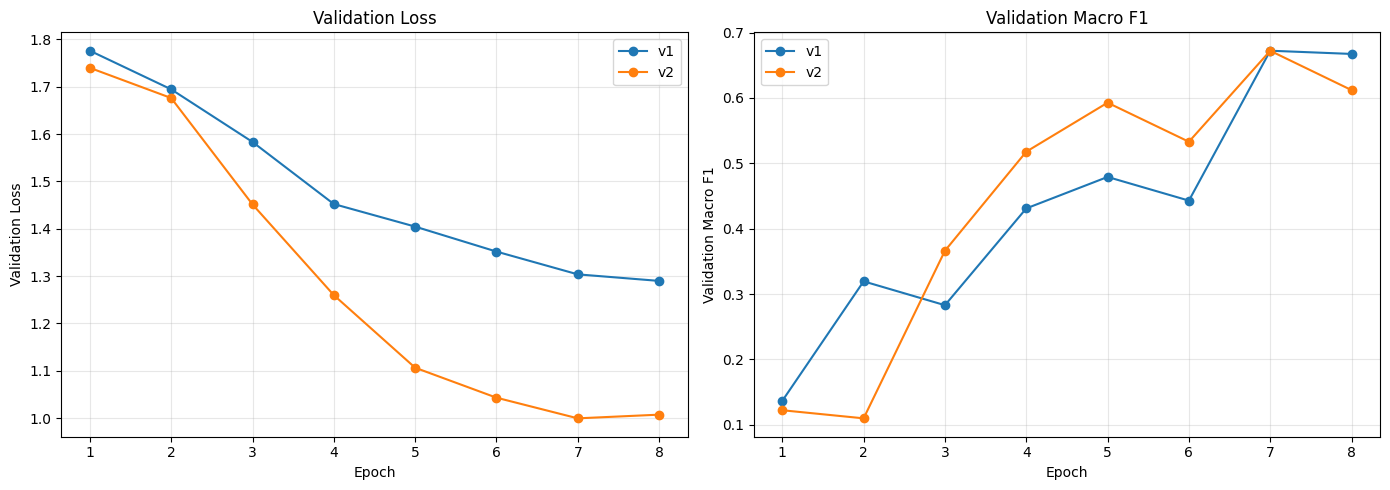

Saved: /content/classifier_outputs/classifier_training_curves.png


In [29]:
def plot_training_curves(version_names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for vname in version_names:
        log_path = OUTPUT_DIR / vname / "log_history.json"
        if not log_path.exists():
            print(f"Missing log: {log_path}")
            continue
        with open(log_path) as f:
            history = json.load(f)

        # Eval metrics per epoch
        eval_epochs = [h["epoch"] for h in history if "eval_loss" in h]
        eval_losses = [h["eval_loss"] for h in history if "eval_loss" in h]
        eval_f1s = [h["eval_f1_macro"] for h in history if "eval_f1_macro" in h]

        axes[0].plot(eval_epochs, eval_losses, marker="o", label=f"{vname}")
        axes[1].plot(eval_epochs, eval_f1s, marker="o", label=f"{vname}")

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Validation Loss")
    axes[0].set_title("Validation Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Validation Macro F1")
    axes[1].set_title("Validation Macro F1")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    save_path = OUTPUT_DIR / "classifier_training_curves.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

plot_training_curves(["v1", "v2"])